# **Video Game Sales Prediction**

## **EDA and Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [ ]:
data = pd.read_csv('/content/video-game-sales.csv')
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.shape

(16719, 16)

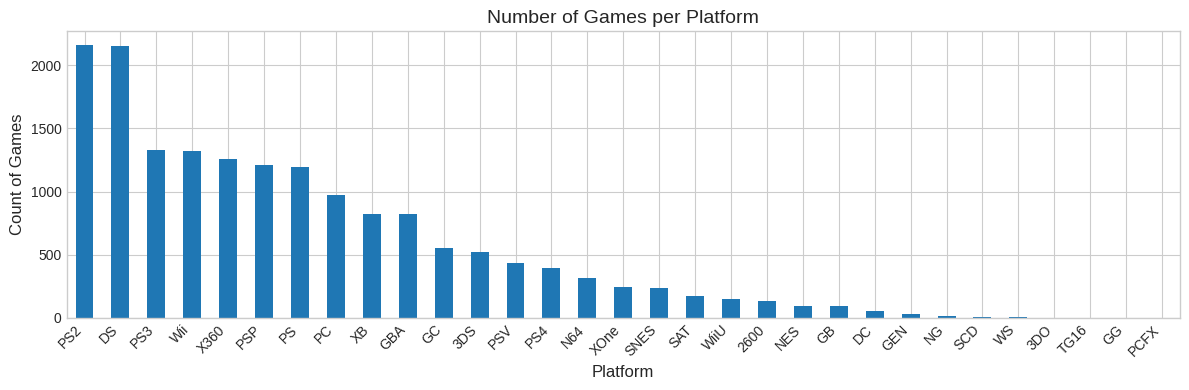

In [ ]:
platform_counts = data['Platform'].value_counts()

plt.figure(figsize=(12,4))
platform_counts.plot(kind='bar')
plt.title('Number of Games per Platform', fontsize=14)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Count of Games', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
data = data[(data['Platform'] == 'PS2') | (data['Platform'] == 'PS3') | (data['Platform'] == 'PS4') |
            (data['Platform'] == 'X360') | (data['Platform'] == 'XOne') | (data['Platform'] == 'Wii') |
             (data['Platform'] == 'WiiU') | (data['Platform'] == 'PC')]

print('DataFrame Shape: ', data.shape)
platform_counts = data['Platform'].value_counts()


DataFrame Shape:  (7835, 16)


In [ ]:
# Missing Values Ratio
missing_ratio = (data.isnull().sum() / len(data)) * 100
missing_ratio[missing_ratio != 0].sort_values(ascending=False).head(16)

,0
Critic_Count,38.162093
Critic_Score,38.162093
User_Count,36.783663
Rating,25.883854
User_Score,25.015954
Developer,24.403318
Year_of_Release,1.786854
Publisher,0.191449


In [ ]:
# Droping high missing ratio columns
data.dropna(subset=['Critic_Count'], inplace=True)
missing_ratio = (data.isnull().sum() / len(data)) * 100
missing_ratio[missing_ratio != 0].sort_values(ascending=False).head(16)

,0
User_Count,6.501548
Year_of_Release,1.940144
Rating,1.465428
User_Score,0.412797
Publisher,0.082559
Developer,0.061920


In [ ]:
# Handling Missing Values
data['User_Count'] = data['User_Count'].fillna(data['User_Count'].mean())
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].median())
data['Rating'] = data['Rating'].fillna(data['Rating'].mode()[0])
data['Developer'] = data['Developer'].fillna(data['Developer'].mode()[0])
data['Publisher'] = data['Publisher'].fillna(data['Publisher'].mode()[0])

In [ ]:
data['User_Score'] = data['User_Score'].replace('tbd', np.nan)
data['User_Score'] = pd.to_numeric(data['User_Score'])
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

In [ ]:
missing_ratio = (data.isnull().sum() / len(data)) * 100
missing_ratio[missing_ratio != 0].sort_values(ascending=False).head(16)

,0


In [ ]:
# Saving the Cleaned Data to a CSV File
data.to_csv('video-game-sales-cleaned.csv')

In [ ]:
# Dropping Irrelavent and Unncessary Features
cols = ['Name', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Developer']
data = data.drop(columns=cols, axis=1)
data.head()

,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii,2006.0,Sports,82.53,76.0,51.0,8.0,322.0,E
2,Wii,2008.0,Racing,35.52,82.0,73.0,8.3,709.0,E
3,Wii,2009.0,Sports,32.77,80.0,73.0,8.0,192.0,E
7,Wii,2006.0,Misc,28.92,58.0,41.0,6.6,129.0,E
8,Wii,2009.0,Platform,28.32,87.0,80.0,8.4,594.0,E


In [ ]:
# Label-Encoding
from sklearn.preprocessing import LabelEncoder

encoders = {}
categorical_columns = ['Platform', 'Genre', 'Rating']
for col in categorical_columns:
  encoder = LabelEncoder()
  data[col] = encoder.fit_transform(data[col])
  encoders[col] = encoder

data.head()

,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,4,2006.0,10,82.53,76.0,51.0,8.0,322.0,0
2,4,2008.0,6,35.52,82.0,73.0,8.3,709.0,0
3,4,2009.0,10,32.77,80.0,73.0,8.0,192.0,0
7,4,2006.0,3,28.92,58.0,41.0,6.6,129.0,0
8,4,2009.0,4,28.32,87.0,80.0,8.4,594.0,0


In [ ]:
# Feature Engineering
data = data.rename(columns={'Year_of_Release':'Game_Age'})
data['Game_Age'] = 2025 - data['Game_Age']
data.head()

,Platform,Game_Age,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,4,19.0,10,82.53,76.0,51.0,8.0,322.0,0
2,4,17.0,6,35.52,82.0,73.0,8.3,709.0,0
3,4,16.0,10,32.77,80.0,73.0,8.0,192.0,0
7,4,19.0,3,28.92,58.0,41.0,6.6,129.0,0
8,4,16.0,4,28.32,87.0,80.0,8.4,594.0,0


In [ ]:
# Z-Score Normalization
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Game_Age', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']
scaler = StandardScaler()

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [ ]:
data.head()

,Platform,Game_Age,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,4,0.599324,10,82.53,0.447772,1.032346,0.653226,0.110439,0
2,4,0.107875,6,35.52,0.874843,2.122508,0.866583,0.673956,0
3,4,-0.137849,10,32.77,0.732486,2.122508,0.653226,-0.078857,0
7,4,0.599324,3,28.92,-0.833444,0.536817,-0.342444,-0.170592,0
8,4,-0.137849,4,28.32,1.230736,2.469378,0.937703,0.506502,0


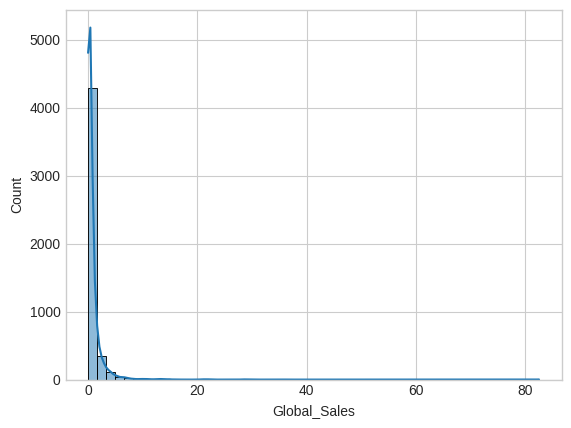

In [ ]:
# Checking the Skewness of Global Sales
sns.histplot(data['Global_Sales'], bins=50, kde=True)
plt.show()

In [ ]:
data['Global_Sales'] = np.log1p(data['Global_Sales'])

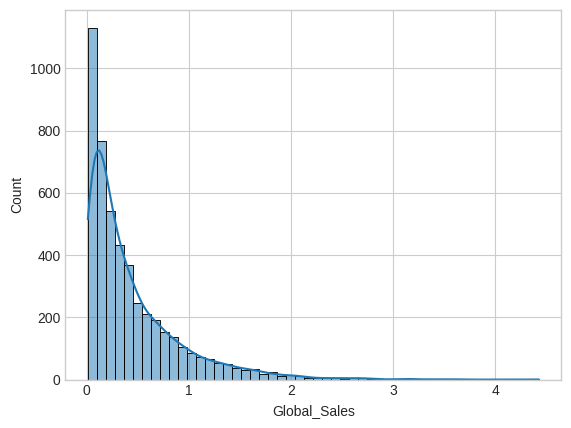

In [ ]:
sns.histplot(data['Global_Sales'], bins=50, kde=True)
plt.show()

## **Model Training and Evaluation**

In [ ]:
# Train-Test Split
X = data.drop(columns=['Global_Sales'], axis=1)
y = data['Global_Sales']
print('Cleaned Dataset Size: ', X.shape)


Cleaned Dataset Size:  (4845, 8)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training Examples: ', X_train.shape)
print('Test Examples: ', X_test.shape)

Training Examples:  (3876, 8)
Test Examples:  (969, 8)


In [ ]:
def plot_regression_results(y_test, y_pred, model_name="Model"):

    plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label='Ideal Fit')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.title(f"{model_name} - Predicted vs Actual")

    plt.tight_layout()
    plt.show()

In [ ]:
models = {'Model':[], 'R2_Score':[], 'RMSE':[]}

### **K-Nearest Neighbors Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

k_values = range(1, 31)
cv_scores = []
for k in k_values:
  knn = KNeighborsRegressor(n_neighbors=k)
  scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2')
  cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print('Optimal K-Neighbors = ', optimal_k)

Optimal K-Neighbors =  9


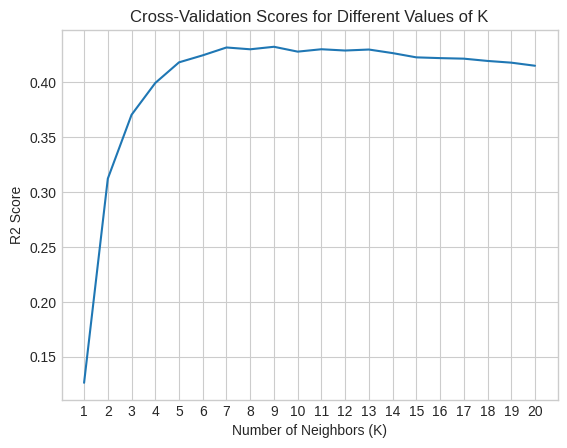

In [ ]:
plt.plot(k_values[:20], cv_scores[:20])
plt.xlabel('Number of Neighbors (K)')
plt.xticks(k_values[:20])
plt.ylabel('R2 Score')
plt.title('Cross-Validation Scores for Different Values of K')
plt.show()

In [ ]:
knn = KNeighborsRegressor(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=9)

In [ ]:
y_pred = knn.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Root Mean Squared Error: ', rmse)
print('R2 Score: ', r2)

Root Mean Squared Error:  0.34626018108269785
R2 Score:  0.5000390604339944


In [ ]:
models['Model'].append('KNN Regression')
models['R2_Score'].append(r2)
models['RMSE'].append(rmse)

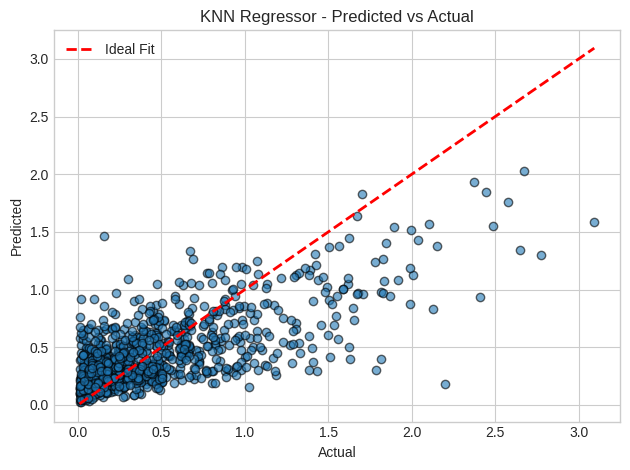

In [ ]:
plot_regression_results(y_test, y_pred, model_name='KNN Regressor')

### **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Root Mean Squared Error: ', rmse)
print('R2 Score: ', r2)

Root Mean Squared Error:  0.38169078603888235
R2 Score:  0.39248875031902164


In [ ]:
models['Model'].append('Linear Regression')
models['R2_Score'].append(r2)
models['RMSE'].append(rmse)

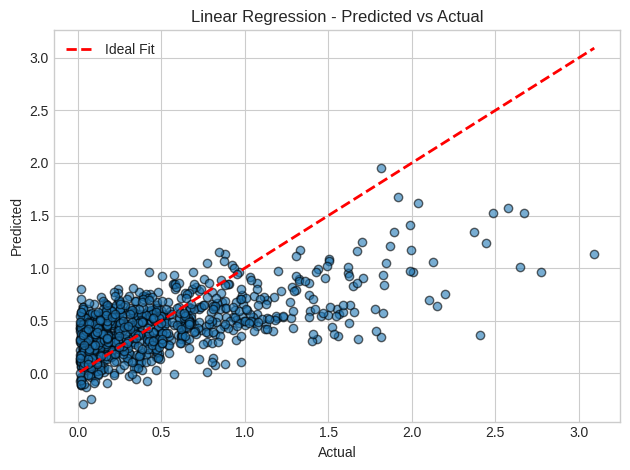

In [ ]:
plot_regression_results(y_test, y_pred, model_name='Linear Regression')

### **Support Vector Regressor**

In [ ]:
from sklearn.svm import SVR

param_grid = {'C': [0.01, 0.1, 1, 10],
               'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
               'kernel': ['rbf']}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

svr = grid.best_estimator_

print('Best Parameters: ', grid.best_params_)

Best Parameters:  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
y_pred = svr.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Root Mean Squared Error: ', rmse)
print('R2 Score: ', r2)

Root Mean Squared Error:  0.33593032844012344
R2 Score:  0.5294244039156646


In [ ]:
models['Model'].append('Support Vector Regressor')
models['R2_Score'].append(r2)
models['RMSE'].append(rmse)

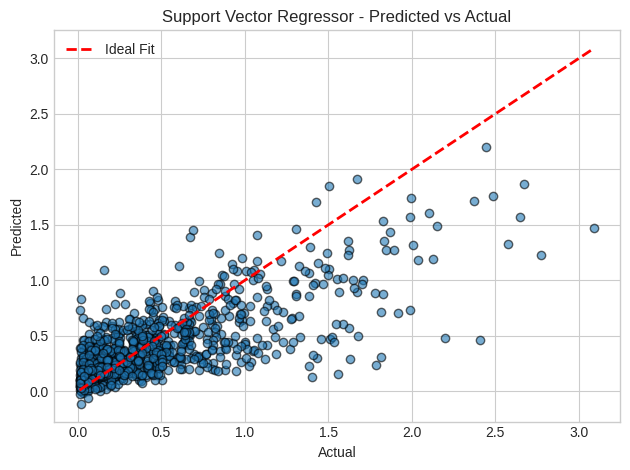

In [ ]:
plot_regression_results(y_test, y_pred, model_name='Support Vector Regressor')

### **Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {'n_estimators': [100, 200, 300],
              'max_depth': [None, 10, 20],
              'min_samples_split': [2, 5, 10]}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

rf_reg = grid.best_estimator_

print('Best Parameters: ', grid.best_params_)

Best Parameters:  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
y_pred = rf_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Root Mean Squared Error: ', rmse)
print('R2 Score: ', r2)

Root Mean Squared Error:  0.29943726503920903
R2 Score:  0.6261110184383097


In [ ]:
models['Model'].append('Random Forest Regressor')
models['R2_Score'].append(r2)
models['RMSE'].append(rmse)

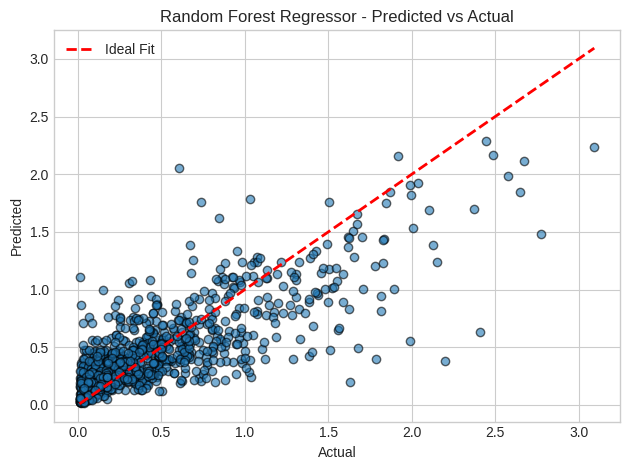

In [ ]:
plot_regression_results(y_test, y_pred, model_name='Random Forest Regressor')

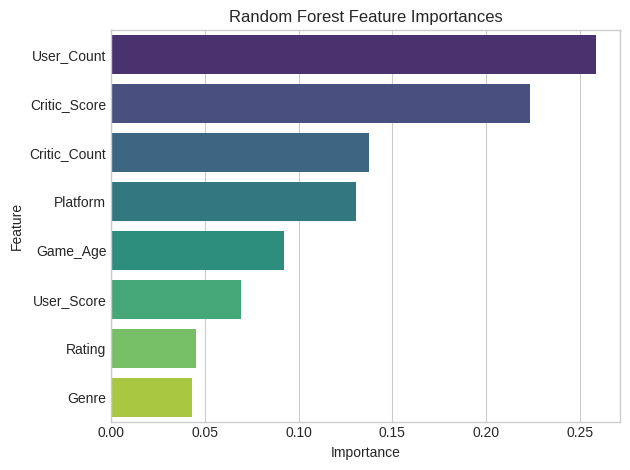

In [ ]:
importances = rf_reg.feature_importances_

feat_df = pd.DataFrame({'Feature': X.columns,'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

sns.barplot(data=feat_df, x='Importance', y='Feature',
    hue='Feature', palette='viridis')

plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### **XG Boost**

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Root Mean Squared Error: 0.2885
R2 Score: 0.6528


In [ ]:
models['Model'].append('XG Boost')
models['R2_Score'].append(r2)
models['RMSE'].append(rmse)

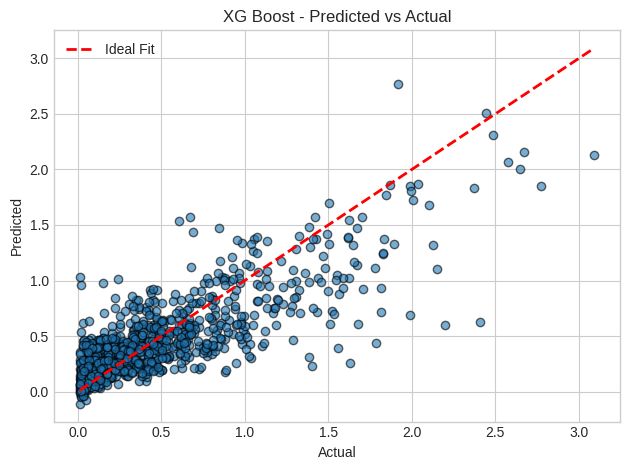

In [ ]:
plot_regression_results(y_test, y_pred, model_name='XG Boost')

## **Final Results**

In [ ]:
model_scores = pd.DataFrame(models)
model_scores = model_scores.sort_values(by='R2_Score', ascending=False).reset_index().drop(columns='index', axis=1)
model_scores

,Model,R2_Score,RMSE
0,XG Boost,0.652830,0.288540
1,Random Forest Regressor,0.626111,0.299437
2,Support Vector Regressor,0.529424,0.335930
3,KNN Regression,0.500039,0.346260
4,Linear Regression,0.392489,0.381691


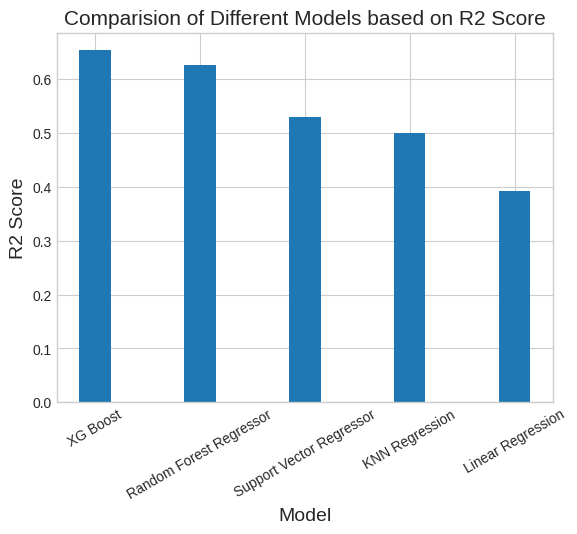

In [ ]:
plt.bar(model_scores['Model'], model_scores['R2_Score'], width=0.3)
plt.xlabel('Model', fontsize=14)
plt.xticks(rotation=30)
plt.ylabel('R2 Score', fontsize=14)
plt.title('Comparision of Different Models based on R2 Score', fontsize=15)
plt.show()

## **Prediting Video Game Sales for User Input**

In [ ]:
# Function to take user input and preprocess it
def preprocess_user_input(platform, year, genre, critic_score, critic_count, user_score, user_count, rating):
    # Create a DataFrame from user input
    user_data = pd.DataFrame({
        'Platform': [platform],
        'Game_Age': [2025 - year],
        'Genre': [genre],
        'Critic_Score': [critic_score],
        'Critic_Count': [critic_count],
        'User_Score': [user_score],
        'User_Count': [user_count],
        'Rating': [rating]
    })


    categorical_cols = ['Platform', 'Genre', 'Rating']
    for col in categorical_cols:
        if col in encoders:
            user_data[col] = encoders[col].transform(user_data[col])
        else:
            print(f"Warning: Encoder for {col} not found. Skipping encoding.")


    numeric_cols = ['Game_Age', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']
    user_data[numeric_cols] = scaler.transform(user_data[numeric_cols])

    return user_data

# Function to predict global sales
def predict_global_sales(user_data, model):
    # Make prediction
    predicted_log_sales = model.predict(user_data)
    # Inverse transform the log scale prediction
    predicted_sales = np.expm1(predicted_log_sales)
    return predicted_sales[0]

# Get user input
print("Please enter the following details for the video game:")

unique_platforms = encoders['Platform'].classes_
unique_genres = encoders['Genre'].classes_
unique_ratings = encoders['Rating'].classes_


# Display options for categorical features
print(f"Available Platforms: {list(unique_platforms)}")
print(f"Available Genres: {list(unique_genres)}")
print(f"Available Ratings: {list(unique_ratings)}")


platform = input("Platform: ")
year = int(input("Year of Release: "))
genre = input("Genre: ")
critic_score = float(input("Critic Score (0-100): "))
critic_count = float(input("Critic Count: "))
user_score = float(input("User Score (0-10): "))
user_count = float(input("User Count: "))
rating = input("Rating: ")


# Preprocess user input
user_input_processed = preprocess_user_input(platform, year, genre, critic_score, critic_count, user_score, user_count, rating)

# Predict global sales using the best model (XG Boost)
predicted_sales = predict_global_sales(user_input_processed, xgb_model)
print(f"\nPredicted Global Sales: {predicted_sales:.2f} million units")

Please enter the following details for the video game:
Available Platforms: ['PC', 'PS2', 'PS3', 'PS4', 'Wii', 'WiiU', 'X360', 'XOne']
Available Genres: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']
Available Ratings: ['E', 'E10+', 'M', 'RP', 'T']
Platform: PS4
Year of Release: 2016
Genre: Racing
Critic Score (0-100): 80
Critic Count: 120
User Score (0-10): 7
User Count: 200
Rating: E

Predicted Global Sales: 0.62 million units
